# RED NEURONAL CONVOLUCIONAL PARA CLASIFICIÓN DE TIPOS DE BASURA RECICLABLE

## IMPORTAMOS LIBRERIAS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CARGAMOS PATH DE IMAGENES

In [ ]:
BASE_DIR = '/content/drive/MyDrive/colab_datasets/garbage_dataset'

In [ ]:
import os
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
print(TRAIN_DIR)
print(VALIDATION_DIR)
print(TEST_DIR)

/content/drive/MyDrive/colab_datasets/garbage_dataset/train
/content/drive/MyDrive/colab_datasets/garbage_dataset/validation
/content/drive/MyDrive/colab_datasets/garbage_dataset/test


## 1 -CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE CADA TIPO DE BASURA

In [ ]:
classes = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
print(f"Garbage classes found: {classes}")

Garbage classes found: ['trash', 'glass', 'metal', 'plastic', 'cardboard', 'paper']


In [ ]:
for class_name in classes:
    # Define train paths for each class
    exec(f"train_{class_name}_dir = os.path.join(TRAIN_DIR, '{class_name}')")
    # Define validation paths for each class
    exec(f"validation_{class_name}_dir = os.path.join(VALIDATION_DIR, '{class_name}')")
    # Define test paths for each class
    exec(f"test_{class_name}_dir = os.path.join(TEST_DIR, '{class_name}')")

print("\n--- Generated Directory Paths ---")
for class_name in classes:
    print(f"train_{class_name}_dir: {eval(f'train_{class_name}_dir')}")
    print(f"validation_{class_name}_dir: {eval(f'validation_{class_name}_dir')}")
    print(f"test_{class_name}_dir: {eval(f'test_{class_name}_dir')}")


--- Generated Directory Paths ---
train_trash_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/train/trash
validation_trash_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/validation/trash
test_trash_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/test/trash
train_glass_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/train/glass
validation_glass_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/validation/glass
test_glass_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/test/glass
train_metal_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/train/metal
validation_metal_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/validation/metal
test_metal_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/test/metal
train_plastic_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/train/plastic
validation_plastic_dir: /content/drive/MyDrive/colab_datasets/garbage_dataset/validation/plastic
test_plast

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def mostrar_imagenes_aleatorias(directorio, num_imagenes=5):
    # Obtener lista de archivos de imagen en el directorio
    imagenes = os.listdir(directorio)

    # Filtrar archivos para obtener solo las imágenes (por ejemplo, con extensiones jpg o png)
    imagenes = [img for img in imagenes if img.endswith(('.jpg', '.jpeg', '.png'))]

    # Seleccionar imágenes aleatorias
    imagenes_aleatorias = random.sample(imagenes, min(num_imagenes, len(imagenes)))

    # Mostrar las imágenes seleccionadas
    for img_name in imagenes_aleatorias:
        img_path = os.path.join(directorio, img_name)
        img = mpimg.imread(img_path)

        plt.figure()
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')  # Ocultar los ejes
        plt.show()

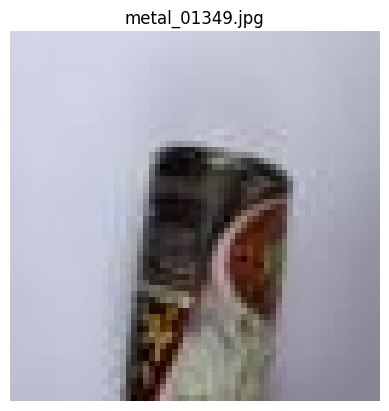

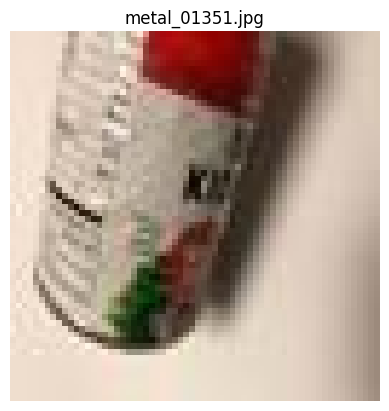

In [ ]:
mostrar_imagenes_aleatorias(test_metal_dir,2)

# Mostramos que cantidades de archivos hay en cada carpeta

In [ ]:
print("\n--- File Counts per Directory ---")
for class_name in classes:
    # Count files in train directory
    train_dir_var = f"train_{class_name}_dir"
    train_count = len(os.listdir(eval(train_dir_var)))
    print(f"{train_dir_var}: {train_count} files")

    # Count files in validation directory
    validation_dir_var = f"validation_{class_name}_dir"
    validation_count = len(os.listdir(eval(validation_dir_var)))
    print(f"{validation_dir_var}: {validation_count} files")

    # Count files in test directory
    test_dir_var = f"test_{class_name}_dir"
    test_count = len(os.listdir(eval(test_dir_var)))
    print(f"{test_dir_var}: {test_count} files")



--- File Counts per Directory ---
train_trash_dir: 10 files
validation_trash_dir: 10 files
test_trash_dir: 10 files
train_glass_dir: 10 files
validation_glass_dir: 10 files
test_glass_dir: 10 files
train_metal_dir: 10 files
validation_metal_dir: 10 files
test_metal_dir: 10 files
train_plastic_dir: 10 files
validation_plastic_dir: 10 files
test_plastic_dir: 10 files
train_cardboard_dir: 10 files
validation_cardboard_dir: 10 files
test_cardboard_dir: 10 files
train_paper_dir: 10 files
validation_paper_dir: 10 files
test_paper_dir: 10 files


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS CON DATA AUGMENTATION

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1. /255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)
val_data = ImageDataGenerator(rescale=1. /255)
test_data = ImageDataGenerator(rescale=1. /255)

## CARGAMOS LOS CONJUNTOS DE DATOS CON LOS OBJETOS CREADOS

In [ ]:
training_set = train_data.flow_from_directory(
    TRAIN_DIR,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical' # Changed to categorical for multi-class
)
validation_set = val_data.flow_from_directory(
    VALIDATION_DIR,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical' # Changed to categorical for multi-class
)
test_set = test_data.flow_from_directory(
    TEST_DIR,
    target_size=(64,64),
    batch_size=32, # Added batch_size for consistency
    class_mode='categorical' # Changed to categorical for multi-class
)

Found 60 images belonging to 6 classes.
Found 60 images belonging to 6 classes.
Found 60 images belonging to 6 classes.


# CREAMOS EL MODELO DE RED CONVOLUCIONAL

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

model = keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(64,64,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6,activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,726 (4.36 MB)

 Trainable params: 1,142,726 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILAMOS EL MODELO

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ENTRENAMOS EL MODELO

In [ ]:
history = model.fit(training_set,epochs=3,batch_size=100,validation_data=validation_set)

Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 21s/step - accuracy: 0.0500 - loss: 2.0130 - val_accuracy: 0.1667 - val_loss: 1.8031
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 904ms/step - accuracy: 0.1667 - loss: 1.8080 - val_accuracy: 0.1500 - val_loss: 1.8065
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step - accuracy: 0.2000 - loss: 1.7722 - val_accuracy: 0.1667 - val_loss: 1.8006


# GRAFICAMOS ACCURACY Y LOSS

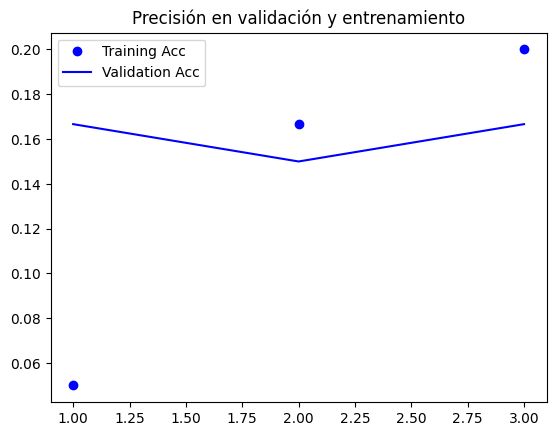

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training Acc')
plt.plot(epochs,val_acc,'b',label='Validation Acc')
plt.title('Precisión en validación y entrenamiento')
plt.legend()
plt.show()

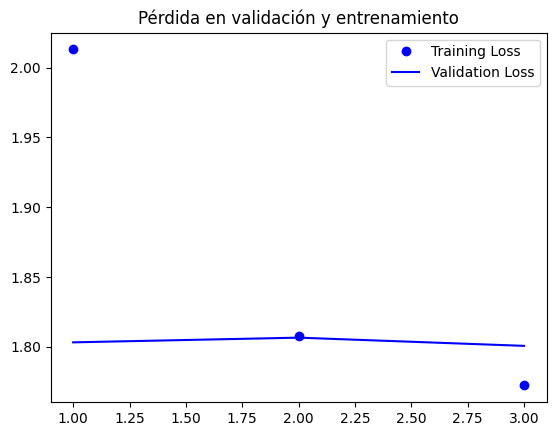

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'b',label='Validation Loss')
plt.title('Pérdida en validación y entrenamiento')
plt.legend()
plt.show()

# EVALUAMOS EL MODELO

In [ ]:
evaluacion = model.evaluate(test_set)
print(evaluacion)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.1500 - loss: 1.7971
[1.7970654964447021, 0.15000000596046448]


# MOSTRAMOS ALGUNAS IMAGENES CON SUS PREDICCIONES

In [ ]:
import numpy as np # Ensure numpy is imported for np.argmax, np.expand_dims

def mostrar_predicciones(model, data_generator, class_names, num_images_to_show=8):
    # Get a batch of images and labels from the generator
    # For visualization, we typically just grab one batch.
    images_batch, labels_batch_one_hot = next(data_generator)

    plt.figure(figsize=(10,5))
    # Iterate over a subset of the batch
    for i in range(min(num_images_to_show, len(images_batch))):
        plt.subplot(2, 4, i+1)
        img = images_batch[i]
        true_label_idx = np.argmax(labels_batch_one_hot[i])

        # Make prediction for a single image (need to expand dimensions for model.predict)
        # The image is already scaled by ImageDataGenerator, so no need for img / 255.0 here
        pred_probabilities = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_label_idx = np.argmax(pred_probabilities)

        # ImageDataGenerator typically rescales images to [0,1] if rescale=1./255 is used.
        # So, imshow can directly display `img`.
        plt.imshow(img)
        plt.title(f'Real: {class_names[true_label_idx]}\nPred: {class_names[pred_label_idx]}', fontsize=10)
        plt.axis('off')
    plt.tight_layout() # Adjust layout to prevent titles from overlapping
    plt.show()


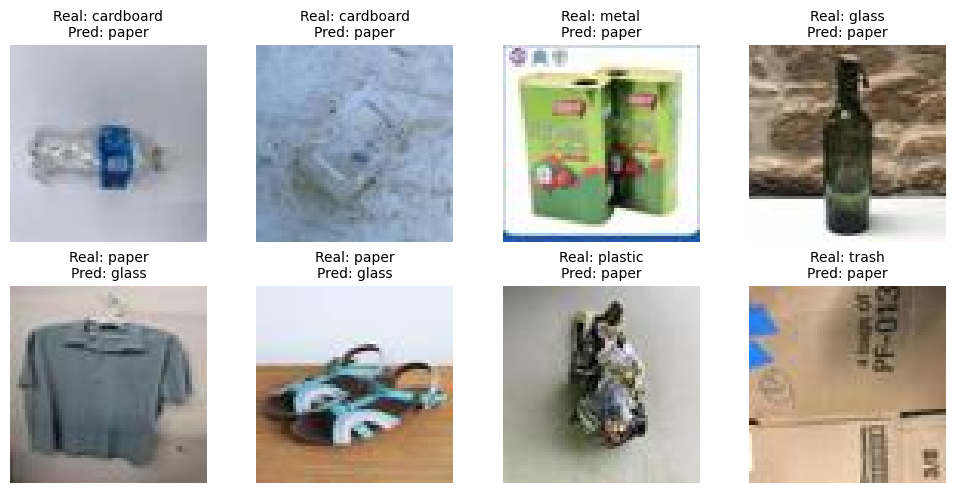

In [ ]:
mostrar_predicciones(model, test_set, classes)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Save the model
model_save_path = "my_garbage_classifier_model.h5"
model.save(model_save_path)
print(f"Modelo guardado en: {model_save_path}")

Modelo guardado en: my_garbage_classifier_model.h5


Modelo cargado exitosamente.

La imagen 'plastic_02566.jpg' es predicha como: paper
Probabilidades de predicción: [0.14514044 0.18097791 0.17316274 0.1475622  0.17139803 0.18175873]


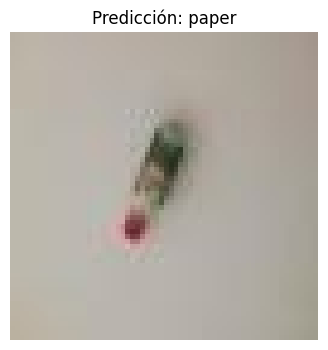

In [ ]:
# 2. Load the model
loaded_model = tf.keras.models.load_model(model_save_path)
print("Modelo cargado exitosamente.")

# 3. Prepare the image for prediction
image_path = '/content/plastic_02566.jpg'
img_size = (64, 64) # Ensure this matches the target_size used in ImageDataGenerator

# Load the image
img = image.load_img(image_path, target_size=img_size)

# Convert the image to a numpy array
img_array = image.img_to_array(img)

# Rescale the image (same as train_data.rescale=1./255)
img_array = img_array / 255.0

# Add a batch dimension (model expects a batch of images)
img_array = np.expand_dims(img_array, axis=0)

# 4. Make a prediction
predictions = loaded_model.predict(img_array, verbose=0)

# Get the predicted class index
predicted_class_index = np.argmax(predictions[0])

# Map the index to the class name
predicted_class_name = classes[predicted_class_index]

print(f"\nLa imagen '{os.path.basename(image_path)}' es predicha como: {predicted_class_name}")
print(f"Probabilidades de predicción: {predictions[0]}")

# 5. Display the image and prediction
plt.figure(figsize=(4, 4))
plt.imshow(img) # Display the loaded PIL image
plt.title(f'Predicción: {predicted_class_name}', fontsize=12)
plt.axis('off')
plt.show()


In [ ]:
import tensorflow as tf
import keras

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")


TensorFlow version: 2.20.0
Keras version: 3.13.2


In [ ]:
%%writefile requirements.txt
tensorflow==2.20.0
keras==3.13.2
numpy
matplotlib
pandas
seaborn


Writing requirements.txt
